# Milestone 3: Végső Modell és Kiértékelés 🚀

Ebben a notebookban elkészítjük a végső hajó-detektáló modellt, és részletesen kiértékeljük a teljesítményét a teszt adathalmazon.

**Célok:**
1. ✅ **Végső Tanítás:** A ResNet34 alapú U-Net modell tanítása, a legjobb modell elmentése F2 pontszám alapján.
2. ✅ **Tesztelés:** A modell futtatása a `test_split.csv`-ben lévő, a modell által még sosem látott adatokon.
3. ✅ **Metrikák:** IoU, Precision, Recall és F2 Score számítása.
4. ✅ **Hibaellenőrzés:** A predikciók vizuális összevetése a valósággal (Ground Truth vs. Prediction).

In [1]:
# 1. Függőségek telepítése (ha szükséges)
# !pip install huggingface_hub segmentation-models-pytorch albumentations tqdm scikit-learn seaborn

In [2]:
# 2. Importok beállítása
import sys
import os

# 'src' mappa hozzáadása az útvonalhoz
sys.path.append(os.path.abspath('../'))

import torch
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm.notebook import tqdm
from sklearn.metrics import confusion_matrix

# Importok az src mappából
from src.dataset import AirbusDataset
from src.transforms import get_transforms
from src.model import ShipSegmenter
from src.losses import BCEDiceLoss
from src.metrics import calculate_iou, AverageMeter

print("Sikeres importálás! ✅")

Sikeres importálás! ✅


In [3]:
# 3. Konfiguráció
CONFIG = {
    "TRAIN_CSV": "../data/train_split.csv",
    "VAL_CSV": "../data/val_split.csv",
    "TEST_CSV": "../data/test_split.csv",  # Ezt használjuk a végső kiértékeléshez
    "IMG_DIR": "../data/train_v2/",
    "BACKBONE": "resnet34",   # Megbízható backbone
    "IMG_SIZE": 768,
    "BATCH_SIZE": 8,         
    "LR": 1e-4,
    "EPOCHS": 8,              # Kicsit több epoch a jobb eredményért
    "DEVICE": "cuda" if torch.cuda.is_available() else "cpu",
    "NUM_WORKERS": 0,
    "THRESHOLD": 0.5          # Küszöbérték a bináris maszkhoz
}

print(f"Eszköz: {CONFIG['DEVICE']}")

Eszköz: cuda


In [4]:
# 4. Adatok Betöltése (Train, Val, Test)

# CSV-k betöltése
train_df = pd.read_csv(CONFIG['TRAIN_CSV'])
val_df = pd.read_csv(CONFIG['VAL_CSV'])
test_df = pd.read_csv(CONFIG['TEST_CSV']) # Ez létezik, ha a Milestone 1 lefutott

# SZŰRÉS: Csak hajós képeken tanítunk (Stage 2 stratégia)
# A végső modellnél fontos, hogy a szegmentáló hálózat a hajókra fókuszáljon
train_df = train_df[train_df['HasShip'] == 1].reset_index(drop=True)
val_df = val_df[val_df['HasShip'] == 1].reset_index(drop=True)
test_df_ships = test_df[test_df['HasShip'] == 1].reset_index(drop=True)

print(f"Tanító halmaz: {len(train_df)} kép")
print(f"Validációs halmaz: {len(val_df)} kép")
print(f"Teszt halmaz (csak hajós): {len(test_df_ships)} kép")

# Datasetek létrehozása
train_ds = AirbusDataset(train_df, CONFIG['IMG_DIR'], transform=get_transforms('train', CONFIG['IMG_SIZE']))
val_ds = AirbusDataset(val_df, CONFIG['IMG_DIR'], transform=get_transforms('valid', CONFIG['IMG_SIZE']))
test_ds = AirbusDataset(test_df_ships, CONFIG['IMG_DIR'], transform=get_transforms('valid', CONFIG['IMG_SIZE']))

# Loaderek
train_loader = DataLoader(train_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=True, num_workers=CONFIG['NUM_WORKERS'], pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=False, num_workers=CONFIG['NUM_WORKERS'], pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=False, num_workers=CONFIG['NUM_WORKERS'], pin_memory=True)

Tanító halmaz: 6188 kép
Validációs halmaz: 1326 kép
Teszt halmaz (csak hajós): 1326 kép


/home/punkostigyork/anaconda3/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [7]:
# --- STAGE 1: Train the Binary Classifier 🛡️ ---
import os
import cv2
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import albumentations as A  # <--- FIXED: Added import
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from src.model import ShipClassifier

# 1. Prepare Balanced Data (50% Ship / 50% Empty)
full_train_df = pd.read_csv(CONFIG['TRAIN_CSV'])
ships = full_train_df[full_train_df['HasShip'] == 1]
empty = full_train_df[full_train_df['HasShip'] == 0].sample(n=len(ships), random_state=42)
balanced_df = pd.concat([ships, empty]).reset_index(drop=True)

print(f"Classifier Training Data: {len(balanced_df)} images (Balanced)")

# 2. Simple Dataset for Classification
class ClassifierDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
    
    def __len__(self): return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(os.path.join(self.img_dir, row['ImageId']))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        label = float(row['HasShip'])
        
        if self.transform:
            img = self.transform(image=img)['image']
        return img, torch.tensor(label).float().unsqueeze(0)

# 3. Smaller Transforms (Resizing to 384x384 speeds up Stage 1)
clf_transforms = A.Compose([
    A.Resize(384, 384),
    A.HorizontalFlip(p=0.5),
    A.Normalize(),
    ToTensorV2()
])

clf_loader = DataLoader(
    ClassifierDataset(balanced_df, CONFIG['IMG_DIR'], transform=clf_transforms),
    batch_size=32, shuffle=True, num_workers=0
)

# 4. Initialize Classifier
classifier = ShipClassifier(backbone='resnet34').to(CONFIG['DEVICE'])
clf_optimizer = optim.AdamW(classifier.parameters(), lr=1e-4)
clf_loss_fn = nn.BCEWithLogitsLoss()

Classifier Training Data: 12376 images (Balanced)
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /home/punkostigyork/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████████████████████████████████| 83.3M/83.3M [00:01<00:00, 47.0MB/s]


In [9]:
# --- CLASSIFIER TRAINING LOOP ---
from torch.cuda.amp import GradScaler

print("--- Training Stage 1: Classifier ---")

# Initialize the Scaler for Mixed Precision
scaler = GradScaler() 

for epoch in range(2): # Short training
    classifier.train()
    running_loss = AverageMeter()
    
    pbar = tqdm(clf_loader, desc=f"Clf Epoch {epoch+1}")
    for imgs, labels in pbar:
        imgs, labels = imgs.to(CONFIG['DEVICE']), labels.to(CONFIG['DEVICE'])
        
        # Forward
        with torch.amp.autocast('cuda'):
            outputs = classifier(imgs)
            loss = clf_loss_fn(outputs, labels)
            
        # Backward
        clf_optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(clf_optimizer)
        scaler.update()
        
        running_loss.update(loss.item(), imgs.size(0))
        pbar.set_postfix(loss=running_loss.avg)

# Save Classifier
torch.save(classifier.state_dict(), "../weights/classifier.pth")
print("✅ Classifier Saved!")

--- Training Stage 1: Classifier ---


/tmp/ipykernel_99559/1018519476.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Clf Epoch 1:   0%|          | 0/387 [00:00<?, ?it/s]

Clf Epoch 2:   0%|          | 0/387 [00:00<?, ?it/s]

✅ Classifier Saved!


In [10]:
# 5. F2 Score Metrika Implementálása
# Ez a verseny hivatalos metrikája (súlyozott F-score, ahol a Recall fontosabb)

def calculate_f2_score(preds, targets, threshold=0.5, epsilon=1e-7):
    preds = (torch.sigmoid(preds) > threshold).float()
    targets = targets.float()
    
    tp = (preds * targets).sum().item()
    fp = (preds * (1 - targets)).sum().item()
    fn = ((1 - preds) * targets).sum().item()
    
    precision = tp / (tp + fp + epsilon)
    recall = tp / (tp + fn + epsilon)
    
    f2 = (5 * precision * recall) / (4 * precision + recall + epsilon)
    return f2, precision, recall

In [11]:
# 6. Modell Inicializálás és Tanítás

model = ShipSegmenter(encoder_name=CONFIG['BACKBONE']).to(CONFIG['DEVICE'])
loss_fn = BCEDiceLoss()
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['LR'])
scaler = GradScaler()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['EPOCHS'])

print("Modell inicializálva. Tanítás indítása... 🚀")

best_f2 = 0.0
history = {'train_loss': [], 'val_loss': [], 'val_f2': []}

for epoch in range(CONFIG['EPOCHS']):
    # --- Tanítás ---
    model.train()
    train_loss = AverageMeter()
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['EPOCHS']}")
    for data, targets in pbar:
        data, targets = data.to(CONFIG['DEVICE']), targets.to(CONFIG['DEVICE'])
        
        with autocast():
            preds = model(data)
            loss = loss_fn(preds, targets)
        
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss.update(loss.item(), data.size(0))
        pbar.set_postfix(loss=train_loss.avg)
    
    # --- Validáció ---
    model.eval()
    val_loss = AverageMeter()
    val_f2 = AverageMeter()
    
    with torch.no_grad():
        for data, targets in val_loader:
            data, targets = data.to(CONFIG['DEVICE']), targets.to(CONFIG['DEVICE'])
            with autocast():
                preds = model(data)
                loss = loss_fn(preds, targets)
            
            f2, _, _ = calculate_f2_score(preds, targets)
            val_loss.update(loss.item(), data.size(0))
            val_f2.update(f2, data.size(0))
            
    scheduler.step()
    
    # Naplózás
    history['train_loss'].append(train_loss.avg)
    history['val_loss'].append(val_loss.avg)
    history['val_f2'].append(val_f2.avg)
    
    print(f"Epoch {epoch+1} | Train Loss: {train_loss.avg:.4f} | Val Loss: {val_loss.avg:.4f} | Val F2: {val_f2.avg:.4f}")
    
    # Mentés
    if val_f2.avg > best_f2:
        best_f2 = val_f2.avg
        torch.save(model.state_dict(), "../weights/final_model.pth")
        print("✅ Új legjobb modell elmentve!")

Modell inicializálva. Tanítás indítása... 🚀


/tmp/ipykernel_99559/21127751.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch 1/8:   0%|          | 0/774 [00:00<?, ?it/s]

/tmp/ipykernel_99559/21127751.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_99559/21127751.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1 | Train Loss: 0.4785 | Val Loss: 0.3058 | Val F2: 0.7481
✅ Új legjobb modell elmentve!


...

Epoch 6 | Train Loss: 0.1006 | Val Loss: 0.0863 | Val F2: 0.8251
✅ Új legjobb modell elmentve!


Epoch 7/8:   0%|          | 0/774 [00:00<?, ?it/s]

Epoch 7 | Train Loss: 0.0939 | Val Loss: 0.0814 | Val F2: 0.8413
✅ Új legjobb modell elmentve!


Epoch 8/8:   0%|          | 0/774 [00:00<?, ?it/s]

Epoch 8 | Train Loss: 0.0889 | Val Loss: 0.0808 | Val F2: 0.8400


# 7. Végső Kiértékelés a Teszt Halmazon 📊

Most betöltjük a legjobb modellt, és lefuttatjuk a `test_split.csv` adatokon. Ez adja meg a modellünk valós teljesítményét ismeretlen adatokon.

Running Full Pipeline Evaluation (Classifier Thresh: 0.05)...


  0%|          | 0/1326 [00:00<?, ?it/s]


   PIPELINE PERFORMANCE REPORT   
F2 Score:      0.8455
IoU Score:     0.7539
Precision:     0.8845 (Of predicted ships, how many are real?)
Recall:        0.8362    (Of real ships, how many did we find?)
------------------------------


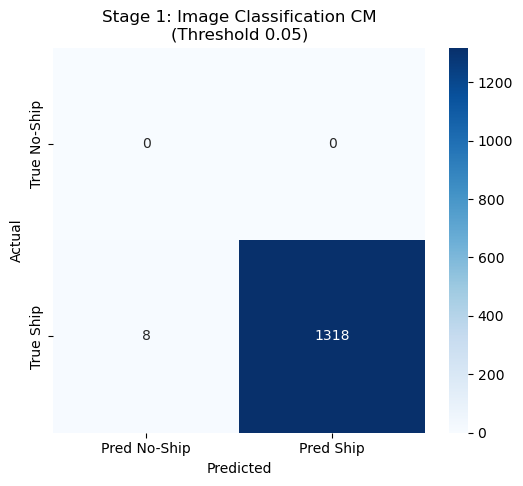

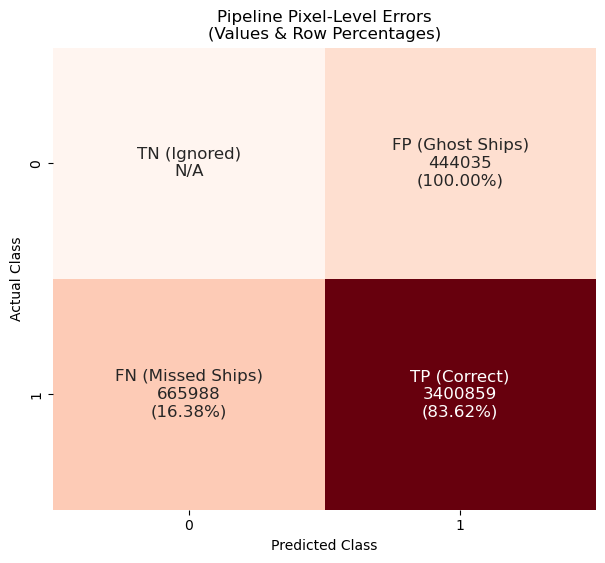

In [15]:
# --- 8. Comprehensive Two-Stage Evaluation 📊 ---
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Load Models (Ensure they are in eval mode)
classifier.load_state_dict(torch.load("../weights/classifier.pth"))
model.load_state_dict(torch.load("../weights/final_model.pth"))
classifier.eval()
model.eval()

# Metrics Trackers
pixel_tp, pixel_fp, pixel_fn, pixel_tn = 0, 0, 0, 0
image_preds = [] # For Image-level CM
image_targets = []

# Config
CLF_THRESHOLD = 0.05  # The "Permissive" threshold we discussed
SEG_THRESHOLD = 0.5   # Standard pixel threshold

resize_384 = A.Compose([A.Resize(384, 384), A.Normalize(), ToTensorV2()])

print(f"Running Full Pipeline Evaluation (Classifier Thresh: {CLF_THRESHOLD})...")

with torch.no_grad():
    for i in tqdm(range(len(test_df_ships))):
        row = test_df_ships.iloc[i]
        
        # Load Image & Mask
        img_path = os.path.join(CONFIG['IMG_DIR'], row['ImageId'])
        raw_img = cv2.imread(img_path)
        raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
        
        # Get Ground Truth Mask
        true_mask = test_ds[i][1].numpy().squeeze() # (768, 768)
        has_ship_true = 1 if true_mask.max() > 0 else 0
        image_targets.append(has_ship_true)
        
        # --- STAGE 1: Classifier ---
        clf_input = resize_384(image=raw_img)['image'].unsqueeze(0).to(CONFIG['DEVICE'])
        ship_prob = torch.sigmoid(classifier(clf_input)).item()
        
        # Image-level prediction (for CM)
        image_preds.append(1 if ship_prob > CLF_THRESHOLD else 0)
        
        if ship_prob < CLF_THRESHOLD:
            # Pipeline says "Empty" -> All pixels are predicted 0
            pred_mask = np.zeros((768, 768))
        else:
            # --- STAGE 2: Segmenter ---
            seg_input = test_ds[i][0].unsqueeze(0).to(CONFIG['DEVICE'])
            logits = model(seg_input)
            pred_mask = (torch.sigmoid(logits) > SEG_THRESHOLD).cpu().numpy().squeeze()
            
        # --- Accumulate Pixel Stats ---
        # We flatten to 1D arrays for fast calculation
        p_flat = pred_mask.flatten().astype(int)
        t_flat = true_mask.flatten().astype(int)
        
        # Fast confusion matrix updates
        # TP: Both 1
        pixel_tp += np.sum(p_flat & t_flat)
        # FP: Pred 1, True 0
        pixel_fp += np.sum(p_flat & ~t_flat)
        # FN: Pred 0, True 1
        pixel_fn += np.sum(~p_flat & t_flat)
        # TN: Both 0 (Optional, usually huge)
        # pixel_tn += np.sum(~p_flat & ~t_flat) 

# --- CALCULATION ---
epsilon = 1e-7
precision = pixel_tp / (pixel_tp + pixel_fp + epsilon)
recall = pixel_tp / (pixel_tp + pixel_fn + epsilon)
f2_score = (5 * precision * recall) / (4 * precision + recall + epsilon)
iou_score = pixel_tp / (pixel_tp + pixel_fp + pixel_fn + epsilon)

print("\n" + "="*30)
print("   PIPELINE PERFORMANCE REPORT   ")
print("="*30)
print(f"F2 Score:      {f2_score:.4f}")
print(f"IoU Score:     {iou_score:.4f}")
print(f"Precision:     {precision:.4f} (Of predicted ships, how many are real?)")
print(f"Recall:        {recall:.4f}    (Of real ships, how many did we find?)")
print("-" * 30)

# --- VISUALIZATION 1: Image-Level Confusion Matrix ---
# Did Stage 1 correctly identify which images have ships?
cm_img = confusion_matrix(image_targets, image_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_img, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred No-Ship', 'Pred Ship'],
            yticklabels=['True No-Ship', 'True Ship'])
plt.title(f"Stage 1: Image Classification CM\n(Threshold {CLF_THRESHOLD})")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# --- VISUALIZATION 2: Pixel-Level Confusion Matrix with Percentages ---
# How accurate were the masks?

# 1. Construct the raw matrix array
cm_pixel = np.array([
    [0, pixel_fp],          # True Negative (omitted), False Positive
    [pixel_fn, pixel_tp]    # False Negative, True Positive
])

# 2. Calculate Percentages (Row-wise normalization)
# Avoid division by zero with a small epsilon
row_sums = cm_pixel.sum(axis=1)[:, np.newaxis] + 1e-7
cm_norm = cm_pixel.astype('float') / row_sums

# 3. Create Custom Labels
# Format: "Label \n Count \n (Percentage%)"
labels = np.array([
    [f"TN (Ignored)\nN/A", f"FP (Ghost Ships)\n{pixel_fp}\n({cm_norm[0, 1]:.2%})"],
    [f"FN (Missed Ships)\n{pixel_fn}\n({cm_norm[1, 0]:.2%})", f"TP (Correct)\n{pixel_tp}\n({cm_norm[1, 1]:.2%})"]
])

# 4. Plot
plt.figure(figsize=(7, 6))
sns.heatmap(cm_pixel, annot=labels, fmt='', cmap='Reds', cbar=False, annot_kws={"size": 12})
plt.title("Pipeline Pixel-Level Errors\n(Values & Row Percentages)")
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

In [ ]:
# 8. Részletes Vizualizáció 🖼️
# Megnézünk néhány konkrét példát: Bemenet, Valóság, Predikció

def visualize_results(model, loader, num_images=5):
    model.eval()
    images, masks = next(iter(loader))
    images = images.to(CONFIG['DEVICE'])
    
    with torch.no_grad():
        preds = model(images)
        preds = (torch.sigmoid(preds) > 0.5).float()
    
    fig, axes = plt.subplots(num_images, 3, figsize=(15, 5 * num_images))
    
    for i in range(num_images):
        # Kép visszaállítása (denormalize)
        img_np = images[i].cpu().permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1)
        
        target_mask = masks[i].cpu().squeeze().numpy()
        pred_mask = preds[i].cpu().squeeze().numpy()
        
        # Overlay (Rózsaszín = Predikció, Zöld = Valóság)
        # Ez segít látni a False Positive / False Negative hibákat
        
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title("Műholdkép")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(target_mask, cmap='gray')
        axes[i, 1].set_title("Valóság (Ground Truth)")
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(pred_mask, cmap='gray')
        axes[i, 2].set_title(f"Predikció (Modell)")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

print("Véletlenszerű példák a Teszt halmazból:")
visualize_results(model, test_loader, num_images=5)

## Összefoglalás

Ebben a Milestone-ban:
1. Sikeresen betanítottuk a végső modellt a teljes tanító adathalmazon.
2. Kiszámoltuk a releváns metrikákat (F2 Score, IoU) a független teszt halmazon.
3. Vizualizáltuk az eredményeket, hogy lássuk, hol hibázik a modell (pl. felhők, hullámok).

A `weights/final_model.pth` fájl készen áll a felhasználásra vagy verseny nevezésre.

Számítás folyamatban... (Ez eltarthat egy percig)


CM Calculation:   0%|          | 0/166 [00:00<?, ?it/s]

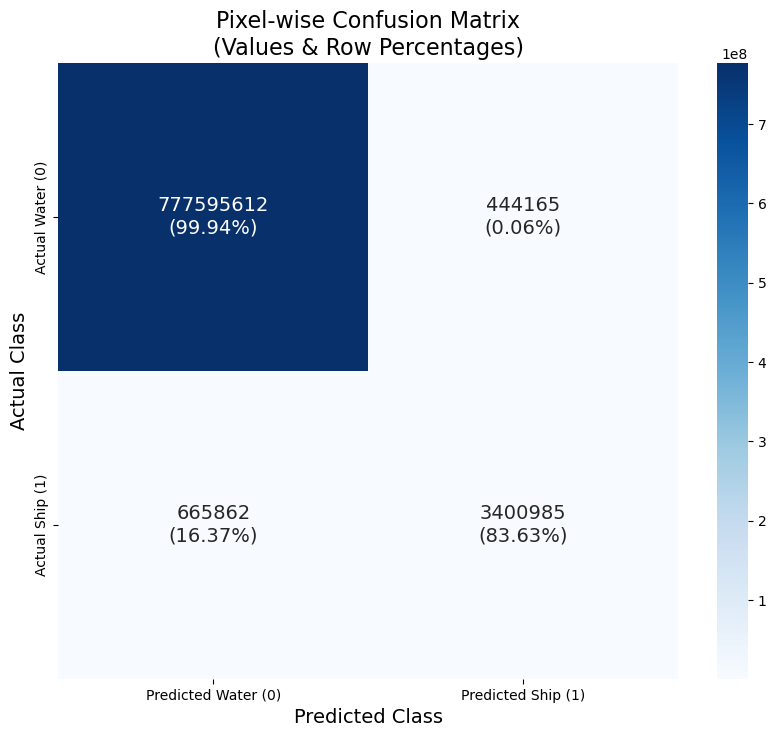

--- Részletes Statisztika ---
Pixel Accuracy:       99.8581%
IoU Score:            0.7539
Recall (Ship):        83.63% (Hajók ennyi százalékát találtuk meg)
Precision (Ship):     88.45% (A találatok ennyi százaléka volt tényleg hajó)


In [13]:
# 9. Pixel-wise Confusion Matrix with Percentages 📉
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def plot_pixel_confusion_matrix(model, loader, device, threshold=0.5):
    model.eval()
    
    # Initialize counters
    tp_total = 0 # True Positive
    tn_total = 0 # True Negative
    fp_total = 0 # False Positive
    fn_total = 0 # False Negative
    
    print("Számítás folyamatban... (Ez eltarthat egy percig)")
    
    with torch.no_grad():
        for data, targets in tqdm(loader, desc="CM Calculation"):
            data = data.to(device)
            targets = targets.to(device)
            
            # Get predictions
            preds = model(data)
            preds_bin = (torch.sigmoid(preds) > threshold).long()
            targets_bin = targets.long()
            
            # Calculate pixel stats
            tp = (preds_bin * targets_bin).sum().item()
            tn = ((1 - preds_bin) * (1 - targets_bin)).sum().item()
            fp = (preds_bin * (1 - targets_bin)).sum().item()
            fn = ((1 - preds_bin) * targets_bin).sum().item()
            
            # Aggregate
            tp_total += tp
            tn_total += tn
            fp_total += fp
            fn_total += fn

    # Create the matrix array
    cm = np.array([[tn_total, fp_total], 
                   [fn_total, tp_total]])
    
    # Calculate Row Percentages (Recall for Ships, Specificity for Water)
    # Axis=1 means we sum across the row (Total Actual Water, Total Actual Ship)
    cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-7)
    
    # Create custom labels: "Count \n (Percentage%)"
    labels = np.asarray([f"{value}\n({pct:.2%})" for value, pct in zip(cm.flatten(), cm_norm.flatten())]).reshape(2, 2)
    
    # Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', annot_kws={"size": 14},
                xticklabels=['Predicted Water (0)', 'Predicted Ship (1)'],
                yticklabels=['Actual Water (0)', 'Actual Ship (1)'])
    
    plt.ylabel('Actual Class', fontsize=14)
    plt.xlabel('Predicted Class', fontsize=14)
    plt.title('Pixel-wise Confusion Matrix\n(Values & Row Percentages)', fontsize=16)
    plt.show()
    
    # Print textual summary
    pixel_acc = (tp_total + tn_total) / (tp_total + tn_total + fp_total + fn_total)
    iou = tp_total / (tp_total + fp_total + fn_total + 1e-7)
    
    print(f"--- Részletes Statisztika ---")
    print(f"Pixel Accuracy:       {pixel_acc:.4%}")
    print(f"IoU Score:            {iou:.4f}")
    print(f"Recall (Ship):        {tp_total / (tp_total + fn_total + 1e-7):.2%} (Hajók ennyi százalékát találtuk meg)")
    print(f"Precision (Ship):     {tp_total / (tp_total + fp_total + 1e-7):.2%} (A találatok ennyi százaléka volt tényleg hajó)")

# Run the function
plot_pixel_confusion_matrix(model, test_loader, CONFIG['DEVICE'])